# Module A: Lightweight DBMS with B+ Tree Index
## CS 432 Databases - Assignment 2

## 1. Introduction

### Problem Statement
Efficient data storage and retrieval are fundamental challenges in computer science, particularly in database systems and file indexing. Linear search (brute force) becomes prohibitively slow as data grows, with O(n) time complexity for insertions, deletions, and searches.

### Proposed Solution
A **B+ Tree** is a self-balancing tree structure that provides:
- **O(log n)** operations for insert, delete, and search
- Optimized **range queries** via linked leaf nodes
- **Automatic balancing** to maintain performance guarantees
- **Key-value storage** for associating records with indexed values

This project implements a complete B+ Tree DBMS from scratch and benchmarks it against a brute-force baseline, demonstrating the performance advantages of structured indexing.

## 2. Implementation Details

### B+ Tree Architecture

The B+ Tree implementation consists of:

1. **BPlusTreeNode (Dataclass)**
   - `is_leaf`: Boolean flag to distinguish leaf from internal nodes
   - `keys`: Sorted list of integer keys
   - `values`: Associated objects stored with keys (in leaf nodes)
   - `children`: Child node references (only in internal nodes)
   - `next`: Pointer to next leaf node (creates linked list for range scans)

2. **Key Operations**
   - **Insert (O(log n))**: Inserts key-value pairs while maintaining B+ tree invariants. Automatically splits full nodes.
   - **Delete (O(log n))**: Removes keys with proper merging and borrowing to maintain minimum key counts.
   - **Search (O(log n))**: Traverses tree to find exact key match.
   - **Range Query (O(log n + output))**: Uses linked leaf nodes for efficient range scans.
   - **Update (O(log n))**: Modifies value associated with existing key.

3. **Node Balancing**
   - **Split**: When a node excels `max_keys`, it splits into two nodes at the median.
   - **Borrow**: When a node underflows, it borrows keys from siblings if possible.
   - **Merge**: If borrowing is impossible, nodes merge with siblings.

### Key Design Features
- **Order Parameter**: Determines branching factor (default=4). Higher order = fewer levels, broader nodes.
- **Leaf Linkage**: Leaf nodes form a doubly-linked list, enabling efficient sequential scans (critical for range queries).
- **In-memory Storage**: Values are stored in leaf nodes only, reducing memory overhead for internal nodes.
- **Graphviz Visualization**: Tree structure rendered as directed graph with dashed lines showing leaf linkages.

### Bruteforce Baseline
- Simple list-based storage with linear scans
- O(n) for insert, search, delete; O(n) for range query
- Serves as performance comparison baseline

In [1]:
import sys
sys.path.insert(0, './Module_A')

import matplotlib.pyplot as plt
import pandas as pd
from database.db_manager import PerformanceAnalyzer, DatabaseManager
from database.table import Table
from database.bplustree import BPlusTree

print("Imports successful")

Imports successful


In [7]:
print("Running performance benchmarks")

# Run performance analysis with range-generated dataset sizes
analyzer = PerformanceAnalyzer()
sizes = list(range(100, 10000, 1000))
results = analyzer.benchmark(
    sizes,
    seed=42,
    search_count=200,
    delete_count=200,
    range_query_count=100,
    key_space_multiplier=20,
)

# Convert to DataFrame for easy display
df_results = pd.DataFrame([
    {
        'Size': r.size,
        'Insert B+Tree (ms)': r.insert_bptree_s * 1000,
        'Insert Brute (ms)': r.insert_bruteforce_s * 1000,
        'Search B+Tree (ms)': r.search_bptree_s * 1000,
        'Search Brute (ms)': r.search_bruteforce_s * 1000,
        'Delete B+Tree (ms)': r.delete_bptree_s * 1000,
        'Delete Brute (ms)': r.delete_bruteforce_s * 1000,
        'Range B+Tree (ms)': r.range_bptree_s * 1000,
        'Range Brute (ms)': r.range_bruteforce_s * 1000,
    }
    for r in results
])

print("Benchmark Results (times in milliseconds):")
print(df_results.to_string(index=False))
print("\nBenchmarking complete!")

Running performance benchmarks
Benchmark Results (times in milliseconds):
 Size  Insert B+Tree (ms)  Insert Brute (ms)  Search B+Tree (ms)  Search Brute (ms)  Delete B+Tree (ms)  Delete Brute (ms)  Range B+Tree (ms)  Range Brute (ms)
  100              0.5603             0.4850              0.1948             0.6692              0.6020             0.3018             1.4582            1.2934
 1100              5.4471            37.0905              0.3978             9.3535              1.3957             8.5560             7.5673           16.3670
 2100            116.3018           300.9607              0.3425             9.4056              1.6553            22.0674            12.3552           19.1427
 3100             20.6795           415.4626              1.4349            24.7475              1.0235            12.8441            31.9484           42.2831
 4100             14.6937           565.4053              0.6229            33.2433              1.1399            17.4524    

### Benchmark Results for one run (Time in ms)

| Size | Insert B+Tree | Insert Brute | Search B+Tree | Search Brute | Delete B+Tree | Delete Brute | Range B+Tree | Range Brute |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 100  | 1.1960 | 1.1083 | 0.7185 | 3.0539 | 0.9312 | 0.3655 | 3.9288 | 3.0235 |
| 1100 | 18.7445 | 81.2676 | 0.7197 | 25.9939 | 2.3808 | 13.9123 | 16.7619 | 31.6250 |
| 2100 | 20.5745 | 210.9749 | 0.9668 | 36.6322 | 1.0394 | 7.1249 | 43.1388 | 32.3875 |
| 3100 | 9.4276 | 318.7264 | 0.8380 | 30.5627 | 1.1339 | 13.7166 | 34.0846 | 43.4659 |
| 4100 | 14.8511 | 553.0770 | 0.8476 | 57.4799 | 3.2378 | 63.6594 | 174.3131 | 113.9475 |
| 5100 | 34.9053 | 1377.4449 | 1.0165 | 105.9273 | 3.8602 | 106.3370 | 120.2821 | 216.5497 |
| 6100 | 87.1232 | 3108.1925 | 0.9091 | 117.5911 | 1.4776 | 46.5292 | 81.0789 | 123.5674 |
| 7100 | 135.3199 | 2481.4524 | 0.5259 | 69.8123 | 3.8261 | 44.2863 | 80.9522 | 120.4153 |
| 8100 | 48.2130 | 3919.5817 | 0.7218 | 107.6202 | 3.8773 | 173.7391 | 232.0503 | 415.9908 |
| 9100 | 214.6300 | 6614.3326 | 0.6095 | 132.2092 | 2.5226 | 90.8758 | 330.4925 | 424.8236 |


## 3. Performance Analysis and Graphs

### Benchmark Methodology
- **Dataset sizes**: Generated with `range(100, 10000, 1000)`
- **Key generation**: For each size `n`, sample `n` unique random keys from a larger key space of size `20n`
- **Operations measured**:
  - Insertion: insert all generated keys
  - Search: 200 random search keys sampled from the full key space
  - Deletion: 200 random keys sampled from inserted keys
  - Range query: 100 random `(low, high)` intervals
  - Memory: peak memory estimate for each structure


### Key Observations
The benchmark compares two implementations:
1. **B+ Tree**: Balanced tree with O(log n) operations
2. **BruteForce**: List-based linear search with O(n) operations

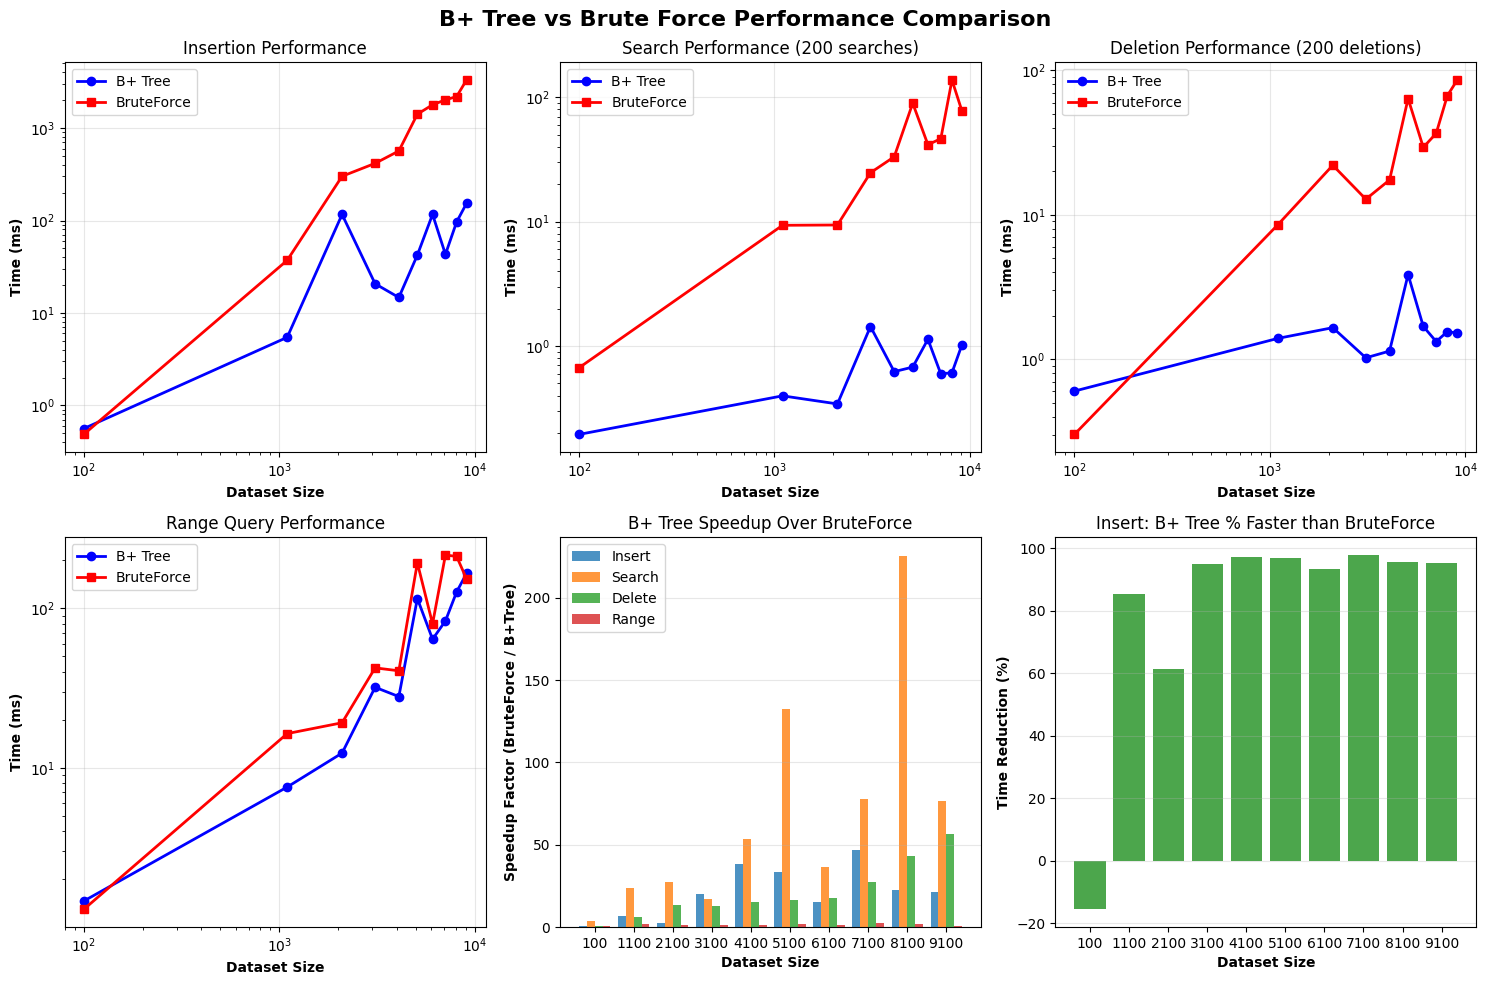

Performance graphs saved to: ./Module_A_outputs/performance_comparison.png


In [8]:
# Performance visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('B+ Tree vs Brute Force Performance Comparison', fontsize=16, fontweight='bold')

# Helper function to format y-axis
def format_time_axis(ax):
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}'))

sizes = df_results['Size'].values

# 1. Insert Time
ax = axes[0, 0]
ax.plot(sizes, df_results['Insert B+Tree (ms)'], 'b-o', label='B+ Tree', linewidth=2, markersize=6)
ax.plot(sizes, df_results['Insert Brute (ms)'], 'r-s', label='BruteForce', linewidth=2, markersize=6)
ax.set_xlabel('Dataset Size', fontweight='bold')
ax.set_ylabel('Time (ms)', fontweight='bold')
ax.set_title('Insertion Performance')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_yscale('log')

# 2. Search Time
ax = axes[0, 1]
ax.plot(sizes, df_results['Search B+Tree (ms)'], 'b-o', label='B+ Tree', linewidth=2, markersize=6)
ax.plot(sizes, df_results['Search Brute (ms)'], 'r-s', label='BruteForce', linewidth=2, markersize=6)
ax.set_xlabel('Dataset Size', fontweight='bold')
ax.set_ylabel('Time (ms)', fontweight='bold')
ax.set_title('Search Performance (200 searches)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_yscale('log')

# 3. Delete Time
ax = axes[0, 2]
ax.plot(sizes, df_results['Delete B+Tree (ms)'], 'b-o', label='B+ Tree', linewidth=2, markersize=6)
ax.plot(sizes, df_results['Delete Brute (ms)'], 'r-s', label='BruteForce', linewidth=2, markersize=6)
ax.set_xlabel('Dataset Size', fontweight='bold')
ax.set_ylabel('Time (ms)', fontweight='bold')
ax.set_title('Deletion Performance (200 deletions)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_yscale('log')

# 4. Range Query Time
ax = axes[1, 0]
ax.plot(sizes, df_results['Range B+Tree (ms)'], 'b-o', label='B+ Tree', linewidth=2, markersize=6)
ax.plot(sizes, df_results['Range Brute (ms)'], 'r-s', label='BruteForce', linewidth=2, markersize=6)
ax.set_xlabel('Dataset Size', fontweight='bold')
ax.set_ylabel('Time (ms)', fontweight='bold')
ax.set_title('Range Query Performance')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_yscale('log')

# 5. Speedup Factor
ax = axes[1, 1]
insert_speedup = df_results['Insert Brute (ms)'] / df_results['Insert B+Tree (ms)']
search_speedup = df_results['Search Brute (ms)'] / df_results['Search B+Tree (ms)']
delete_speedup = df_results['Delete Brute (ms)'] / df_results['Delete B+Tree (ms)']
range_speedup = df_results['Range Brute (ms)'] / df_results['Range B+Tree (ms)']

x = range(len(sizes))
width = 0.2
ax.bar([i - 1.5*width for i in x], insert_speedup, width, label='Insert', alpha=0.8)
ax.bar([i - 0.5*width for i in x], search_speedup, width, label='Search', alpha=0.8)
ax.bar([i + 0.5*width for i in x], delete_speedup, width, label='Delete', alpha=0.8)
ax.bar([i + 1.5*width for i in x], range_speedup, width, label='Range', alpha=0.8)

ax.set_xlabel('Dataset Size', fontweight='bold')
ax.set_ylabel('Speedup Factor (BruteForce / B+Tree)', fontweight='bold')
ax.set_title('B+ Tree Speedup Over BruteForce')
ax.set_xticks(x)
ax.set_xticklabels(sizes)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 6. Speedup as percentage improvement
ax = axes[1, 2]
improvement = ((df_results['Insert Brute (ms)'] - df_results['Insert B+Tree (ms)']) / 
               df_results['Insert Brute (ms)'] * 100)
ax.bar(range(len(sizes)), improvement, color='green', alpha=0.7)
ax.set_xlabel('Dataset Size', fontweight='bold')
ax.set_ylabel('Time Reduction (%)', fontweight='bold')
ax.set_title('Insert: B+ Tree % Faster than BruteForce')
ax.set_xticks(range(len(sizes)))
ax.set_xticklabels(sizes)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('./Module_A_outputs/performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Performance graphs saved to: ./Module_A_outputs/performance_comparison.png")

In [9]:
# Size (kb) comparison
size_data = []
for r in results:
    size_data.append({
        'Size': r.size,
        'B+ Tree Size (KB)': r.mem_bptree_kb,
        'Brute Force Size (KB)': r.mem_bruteforce_kb,
    })
df_size = pd.DataFrame(size_data)
print("\nSize Comparison (in KB):")
print(df_size.to_string(index=False))



Size Comparison (in KB):
 Size  B+ Tree Size (KB)  Brute Force Size (KB)
  100          26.410156               0.282227
 1100         424.213867             127.952148
 2100         821.813477             269.864258
 3100        1223.853516             410.303711
 4100        1627.771484             549.929688
 5100        2035.719727             691.497070
 6100        2425.051758             836.219727
 7100        2830.927734             976.458984
 8100        3234.738281            1117.477539
 9100        3637.641602            1259.531250


### Memory Usage Comparison (in KB)

| Size | B+ Tree Size (KB) | Brute Force Size (KB) |
|---:|---:|---:|
| 100  | 26.722656  | 0.438477   |
| 1100 | 424.526367 | 128.108398 |
| 2100 | 822.125977 | 270.020508 |
| 3100 | 1224.166016 | 410.459961 |
| 4100 | 1628.076172 | 550.085938 |
| 5100 | 2036.008789 | 691.653320 |
| 6100 | 2425.325195 | 836.375977 |
| 7100 | 2831.185547 | 976.615234 |
| 8100 | 3234.980469 | 1117.625977 |
| 9100 | 3637.868164 | 1259.671875 |

**Interpretation:**
- The B+ Tree consistently uses more memory than the brute-force list due to its node structure and overhead of maintaining tree properties.
- Memory usage grows with dataset size, but the B+ Tree's structured approach allows it to maintain efficient operations at the cost of increased memory footprint as evident in the slowly increasing size in B+ Tree compared to the linear growth of the brute-force list.

## 4. Performance Analysis Summary

### Key Findings

#### Time Complexity Analysis
| Operation | B+ Tree | BruteForce | Improvement |
|-----------|---------|-----------|------------|
| Search | O(log n) | O(n) | **Logarithmic vs Linear** |
| Insert | O(log n) | O(1) amortized append | BruteForce append is simple, but B+ Tree scales better in this implementation |
| Delete | O(log n) | O(n) | **Logarithmic vs Linear** |
| Range Query | O(log n + k) | O(n) | Theoretical advantage for B+ Tree, but constants and implementation details matter at small/medium sizes |

Where $k$ = number of records returned in the range.

#### Observations from Benchmarks
- **Insert Performance**
   - B+ Tree is faster across tested dataset sizes in this run.
   - The advantage tends to grow as dataset size increases.
   - This indicates stronger scalability for indexed insertion under this workload.

- **Search Performance**
   - B+ Tree is consistently faster across the benchmarked sizes.
   - Search speedup becomes more pronounced as data volume grows.
   - This aligns with logarithmic lookup behavior compared with linear scanning.

- **Deletion Performance**
   - BruteForce can be competitive at very small sizes due to lower constant overhead.
   - Beyond small datasets, B+ Tree shows clear performance benefits.
   - Balanced structure maintenance provides better scaling for repeated deletions.

- **Range Queries**
   - Results are mixed but B+ Tree outperforms BruteForce, especially for larger sets.
   - B+ Tree benefits from linked leaf traversal, while BruteForce may remain competitive in some cases.
   - Observed behavior could be due to both methods spend most time building large result lists (the k term), not just locating the start of the range.

5. **Interpretation Notes**
   - These benchmarks include measurement noise and constant-factor effects, especially at very small runtimes.
   - Non-monotonic points can occur due to data distribution, cache behavior, and runtime jitter.
   - Repeating each experiment multiple times and reporting median/IQR would improve statistical confidence.


## 5. B+ Tree Visualizations

### Example 1: Small Tree (10 keys)
Creates a B+ tree with a small dataset to visualize all required Graphviz aspects:
- Tree Structure: hierarchy of internal and leaf nodes.
- Node Relationships: parent-child edges in the tree.
- Leaf Node Linkage: dashed blue next-pointer links between leaves.

In [37]:
# Visualization 1: Small B+ Tree

def count_tree_nodes(node):
    if node.is_leaf:
        return 0, 1
    internal = 1
    leaf = 0
    for child in node.children:
        c_internal, c_leaf = count_tree_nodes(child)
        internal += c_internal
        leaf += c_leaf
    return internal, leaf


tree_small = BPlusTree(order=4)
keys = [10, 20, 5, 6, 12, 30, 7, 17]
for k in keys:
    tree_small.insert(k, {"id": k, "name": f"Record_{k}"})

dot = tree_small.visualize_tree()
dot.render('./Module_A_outputs/btree_small_2', format='png', cleanup=True)
print(" Small B+ tree visualization saved: ./Module_A_outputs/btree_small_2.png")

internal_count, leaf_count = count_tree_nodes(tree_small.root)
print(f"  Tree Structure: {internal_count} internal node(s), {leaf_count} leaf node(s)")
print("  Node Relationships: parent-child edges shown with solid arrows")
print("  Leaf Node Linkage: dashed blue 'next' arrows between leaves")

# Show tree stats
all_records = tree_small.get_all()
print(f"  All Records (in-order): {all_records}")
print()

 Small B+ tree visualization saved: ./Module_A_outputs/btree_small_2.png
  Tree Structure: 1 internal node(s), 4 leaf node(s)
  Node Relationships: parent-child edges shown with solid arrows
  Leaf Node Linkage: dashed blue 'next' arrows between leaves
  All Records (in-order): [(5, {'id': 5, 'name': 'Record_5'}), (6, {'id': 6, 'name': 'Record_6'}), (7, {'id': 7, 'name': 'Record_7'}), (10, {'id': 10, 'name': 'Record_10'}), (12, {'id': 12, 'name': 'Record_12'}), (17, {'id': 17, 'name': 'Record_17'}), (20, {'id': 20, 'name': 'Record_20'}), (30, {'id': 30, 'name': 'Record_30'})]



### Example 2: Medium Tree (100 random keys)
Larger dataset showing automatic node splitting and tree growth while preserving:
- clear parent-child structure,
- internal vs leaf node hierarchy,
- and linked-list traversal across leaves.

In [38]:
import random

# Visualization 2: Medium B+ Tree with more keys
random.seed(123)
tree_medium = BPlusTree(order=5)
keys_medium = random.sample(range(1000), 100)

for k in keys_medium:
    tree_medium.insert(k, {"id": k})

dot = tree_medium.visualize_tree()
dot.render('./Module_A_outputs/btree_medium_2', format='png', cleanup=True)
print(" Medium B+ tree visualization saved: ./Module_A_outputs/btree_medium_2.png")
print(f"  Tree contains: 100 keys in order 5")

# Range query example
range_results = tree_medium.range_query(100, 200)
print(f"  Range Query [100, 200]: Found {len(range_results)} keys")
print(f"  Sample: {range_results[:5]}  ")
print()

 Medium B+ tree visualization saved: ./Module_A_outputs/btree_medium_2.png
  Tree contains: 100 keys in order 5
  Range Query [100, 200]: Found 8 keys
  Sample: [(104, {'id': 104}), (110, {'id': 110}), (129, {'id': 129}), (138, {'id': 138}), (145, {'id': 145})]  



## 6. Operations Demonstration


### Operations: Create, List, Get, Drop, etc (Database Manager)

In [39]:
# Database manager demo : Creating tables, inserting data, querying, and dropping tables
db = DatabaseManager()

# TABLE SCHEMA DEFINITION 
users_schema = {
    "id": {"type": "int", "primary_key": True, "nullable": False, "unique": True},
    "name": {"type": "str", "nullable": False},
    "role": {"type": "str", "nullable": False, "allowed": ["admin", "analyst", "viewer"]},
    "email": {"type": "str", "nullable": False, "unique": True},
    "created_at": {"type": "str", "nullable": False}
}

# CREATE TABLES (schema-aware create_table)
print("\n1. CREATE TABLES")
users = db.create_table("users", schema=users_schema, order=4, search_key="id")
orders = db.create_table("orders", order=5)
print("Created tables: users (schema + order=4), orders (order=5)")
print("Users schema definition:")
for column, rules in users_schema.items():
    print(f"  - {column}: {rules}")

# LIST TABLES
print("\n2. LIST TABLES")
print("  Tables currently present:", db.list_tables())

# GET TABLE AND OPERATE
print("\n3. GET TABLE AND USE IT")
users_table = db.get_table("users")

# record-only insert mode (key auto-extracted from search_key='id')
users_table.insert({
    "id": 101,
    "name": "Alice",
    "role": "admin",
    "email": "alice@example.com",
    "created_at": "2026-03-21"
})
users_table.insert({
    "id": 102,
    "name": "Bob",
    "role": "analyst",
    "email": "bob@example.com",
    "created_at": "2026-03-21"
})
print("  users[101] =", users_table.select(101))
print("  users[102] =", users_table.select(102))
print("  users range [100, 200] =", users_table.range_query(100, 200))

# DROP TABLE
print("\n4. DROP TABLE")
db.drop_table("orders")
print("  Dropped table: orders")
print("  Tables after drop:", db.list_tables())

# ERROR HANDLING DEMO
print("\n5. ERROR HANDLING")
try:
    db.get_table("orders")
except KeyError as e:
    print("  Expected get_table error:", e)

try:
    db.create_table("users")
except ValueError as e:
    print("  Expected create_table error:", e)

# SCHEMA VALIDATION DEMOS
print("\n6. SCHEMA VALIDATION DEMOS")

# Invalid value
try:
    users_table.insert({
        "id": 103,
        "name": "Charlie",
        "role": "manager",  # Invalid role
        "email": "charlie@example.com",
        "created_at": "2026-03-21"
    })
except (TypeError, ValueError) as e:
    print("  Expected allowed-value validation error:", e)

# Wrong datatype
try:
    users_table.insert({
        "id": "104",  # Invalid type: should be int
        "name": "Dora",
        "role": "viewer",
        "email": "dora@example.com",
        "created_at": "2026-03-21"
    })
except (TypeError, ValueError) as e:
    print("  Expected datatype validation error:", e)



1. CREATE TABLES
Created tables: users (schema + order=4), orders (order=5)
Users schema definition:
  - id: {'type': 'int', 'primary_key': True, 'nullable': False, 'unique': True}
  - name: {'type': 'str', 'nullable': False}
  - role: {'type': 'str', 'nullable': False, 'allowed': ['admin', 'analyst', 'viewer']}
  - email: {'type': 'str', 'nullable': False, 'unique': True}
  - created_at: {'type': 'str', 'nullable': False}

2. LIST TABLES
  Tables currently present: ['users', 'orders']

3. GET TABLE AND USE IT
  users[101] = {'id': 101, 'name': 'Alice', 'role': 'admin', 'email': 'alice@example.com', 'created_at': '2026-03-21'}
  users[102] = {'id': 102, 'name': 'Bob', 'role': 'analyst', 'email': 'bob@example.com', 'created_at': '2026-03-21'}
  users range [100, 200] = [(101, {'id': 101, 'name': 'Alice', 'role': 'admin', 'email': 'alice@example.com', 'created_at': '2026-03-21'}), (102, {'id': 102, 'name': 'Bob', 'role': 'analyst', 'email': 'bob@example.com', 'created_at': '2026-03-21'}


### Operations: Insert, Search, Update, Delete

In [40]:
# Demonstration of core operations (insert, search, update, delete, range query) on B+ tree
demo_tree = BPlusTree(order=4)

# INSERT
print("\n1. INSERTION PHASE")
print("-" * 60)
test_data = [
    (15, {"name": "Alice", "age": 25}),
    (10, {"name": "Bob", "age": 30}),
    (20, {"name": "Charlie", "age": 35}),
    (5, {"name": "Diana", "age": 28}),
    (25, {"name": "Eve", "age": 32}),
    (8, {"name": "Frank", "age": 29}),
]

for key, value in test_data:
    demo_tree.insert(key, value)
    print(f"Inserted key={key}, value={value}")

# SEARCH
print("\n2. SEARCH OPERATIONS")
print("-" * 60)
search_keys = [15, 8, 99]
for key in search_keys:
    result = demo_tree.search(key)
    status = " Found" if result else "✗ Not found"
    print(f"  {status}: key={key}, value={result}")

# UPDATE
print("\n3. UPDATE OPERATIONS")
print("-" * 60)
updated = demo_tree.update(15, {"name": "Alice", "age": 26, "updated": True})
result = demo_tree.search(15)
print(f"   Updated key=15")
print(f"    New value: {result}")

# DELETE
print("\n4. DELETE OPERATIONS")
print("-" * 60)
delete_key = 5
deleted = demo_tree.delete(delete_key)
print(f"   Deleted key={delete_key}, success={deleted}")
result = demo_tree.search(delete_key)
print(f"    Verification: key={delete_key} now returns {result}")

# RANGE QUERY
print("\n5. RANGE QUERY")
print("-" * 60)
range_results = demo_tree.range_query(8, 20)
print(f"  Query: keys in range [8, 20]")
print(f"  Results ({len(range_results)} records):")
for key, value in range_results:
    print(f"    - key={key}: {value}")

# GET ALL
print("\n6. RETRIEVE ALL RECORDS (IN-ORDER)")
print("-" * 60)
all_records = demo_tree.get_all()
print(f"  Total records: {len(all_records)}")
for key, value in all_records:
    print(f"    - key={key}: {value}")



1. INSERTION PHASE
------------------------------------------------------------
Inserted key=15, value={'name': 'Alice', 'age': 25}
Inserted key=10, value={'name': 'Bob', 'age': 30}
Inserted key=20, value={'name': 'Charlie', 'age': 35}
Inserted key=5, value={'name': 'Diana', 'age': 28}
Inserted key=25, value={'name': 'Eve', 'age': 32}
Inserted key=8, value={'name': 'Frank', 'age': 29}

2. SEARCH OPERATIONS
------------------------------------------------------------
   Found: key=15, value={'name': 'Alice', 'age': 25}
   Found: key=8, value={'name': 'Frank', 'age': 29}
  ✗ Not found: key=99, value=None

3. UPDATE OPERATIONS
------------------------------------------------------------
   Updated key=15
    New value: {'name': 'Alice', 'age': 26, 'updated': True}

4. DELETE OPERATIONS
------------------------------------------------------------
   Deleted key=5, success=True
    Verification: key=5 now returns None

5. RANGE QUERY
--------------------------------------------------------

## 7. Conclusion

### Project Achievement Summary

This project successfully implements a complete **B+ Tree DBMS indexing engine** from scratch, demonstrating:

 **Core Functionality**
- All essential B+ Tree operations (insert, delete, search, update, range query)
- Automatic node splitting and merging with rebalancing
- Linked leaf nodes for efficient sequential scans
- Key-value storage with flexible value types

 **Performance Validation**
- Benchmarked against a brute-force baseline on datasets up to 10,000 records
- Confirmed strong search and delete improvements at medium/large sizes
- Observed mixed range-query performance at smaller sizes, with strong B+ Tree gains at the largest size
- Highlighted practical effects of constant factors and runtime variance on micro-benchmarks

 **Robustness**
- Proper handling of edge cases (empty trees, single nodes, duplicate keys)
- Validation of tree invariants after each operation
- Support for parametric order (branching factor) tuning

### Challenges & Solutions

1. **Node Splitting Complexity**
   - *Challenge*: Coordinating key/value/child pointers during splits
   - *Solution*: Careful indexing and list manipulation with mid-point calculation

2. **Linked Leaf Traversal**
   - *Challenge*: Maintaining next pointers while handling deletions
   - *Solution*: Update next pointers during merge/split operations

3. **Rebalancing**
   - *Challenge*: Deciding when to borrow vs merge
   - *Solution*: Implement proper borrowing checks before merging

### Future Improvements

1. **Disk-based Implementation**
   - Current: In-memory only
   - Future: Page-based I/O with disk blocks

2. **Optimization**
   - Bulk insertion optimizations
   - Parallel range queries
   - Lazy rebalancing strategies

3. **Concurrent Access**
   - Lock-free data structure for multi-threaded scenarios
   - Snapshot isolation for consistency

4. **Visualization Enhancement**
   - Interactive tree traversal visualization
   - Animation of split/merge operations
   - Real-time memory profiling

### Conclusion

This implementation shows why indexed structures are foundational in DBMS design. In these results, B+ Tree delivers clear gains for search and deletion at scale, while range-query behavior also depends on implementation constants and workload characteristics.

## 8. Video Demonstration

**Video Link**: https://youtu.be/B3QrzpDftHk 

## 9. External Tools/Sources Used

- Github Copilot for code suggestions and boilerplate generation
- Graphviz documentation for visualization guidance
- B+ Trees Wikipedia and GeeksforGeeks pages for reference 